# Training Script for ML Time Series Models


## Settings and Imports


In [3]:
#!/usr/bin/env python3
import os
import joblib
import pandas as pd
import numpy as np

from utils.data_preparation import prepare_data_for_modeling
from utils.visualize_model_performance import evaluate_and_plot_model_sklearn

# Set to True if you want to retrain the model (e.g. after changing features or target)
RETRAIN = True
# Set to True if you want to reprocess the data (e.g. after changing features or target)
REPROCESS_DATA = False
# Default date ranges for training, validation, and testing. 
TRAIN_START_DATE = "2020-01-01"
TRAIN_END_DATE = "2023-12-31"
VALIDATION_START_DATE = "2024-01-01"
VALIDATION_END_DATE = "2024-12-31"
TEST_START_DATE = "2025-01-01"
TEST_END_DATE = "2025-12-31"

os.makedirs("data", exist_ok=True)
os.makedirs("models", exist_ok=True)

# This features describe today's weather and load. We predict next-day load.
FEATURES_TODAY = ['Temp', 'Min Temp', 'Max Temp', 'Wind Speed',
                  'Sunshine Duration', 'Cloud Cover', 'Cooling Degrees', 'Heating Degrees', 'load', 'load_lag_1',
                  'load_lag_7', 'load_lag_14', 'rolling_mean_7', 'rolling_mean_14', 'std_7', 'std_14']

# Temporal features
FEATURES_TIME = ['is_holiday', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']

# Remove weak features based on feature-importance + SHAP analysis
LOW_IMPORTANCE_FEATURES = ['Cooling Degrees', 'Sunshine Duration', 'Cloud Cover', 'Heating Degrees', 'Wind Speed', 'std_7', 'std_14']
REDUCED_FEATURES = [feature for feature in FEATURES_TODAY if feature not in LOW_IMPORTANCE_FEATURES]

FEATURES = REDUCED_FEATURES + FEATURES_TIME

# We will predict the load of the next day
TARGET = "load_t+1"

# No need to scale binary features and already encoded cyclic features
SCALE_FEATURES = REDUCED_FEATURES

print(f"Using {len(FEATURES)} features for retraining: {FEATURES}")

Using 14 features for retraining: ['Temp', 'Min Temp', 'Max Temp', 'load', 'load_lag_1', 'load_lag_7', 'load_lag_14', 'rolling_mean_7', 'rolling_mean_14', 'is_holiday', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos']


## Dataset Loading and Preparation


In [4]:
data_dict, _ = prepare_data_for_modeling(
    FEATURES, TARGET, SCALE_FEATURES, save_scaler=True, save_data=True,
    train_start_date=TRAIN_START_DATE, train_end_date=TRAIN_END_DATE,
    val_start_date=VALIDATION_START_DATE, val_end_date=VALIDATION_END_DATE,
    test_start_date=TEST_START_DATE, test_end_date=TEST_END_DATE,
    reprocess_data=REPROCESS_DATA,
    production_data=False
)

# Training Data
X_train_scaled = data_dict['X_train_scaled']
X_train = data_dict['X_train']
y_train = data_dict['y_train']

# Validation Data
X_val_scaled = data_dict['X_val_scaled']
X_val = data_dict['X_val']
y_val = data_dict['y_val']

# Test Data
X_test_scaled = data_dict['X_test_scaled']
X_test = data_dict['X_test']
y_test = data_dict['y_test']

# Keep feature names on scaled matrices to avoid sklearn warnings
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=FEATURES, index=X_train.index)
X_val_scaled_df = pd.DataFrame(X_val_scaled, columns=FEATURES, index=X_val.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=FEATURES, index=X_test.index)

test_df = data_dict['test_df'].copy()  # Keep non-feature columns such as timestamps

# Inspection
X_test_scaled_df.describe()

,Temp,Min Temp,Max Temp,load,load_lag_1,load_lag_7,load_lag_14,rolling_mean_7,rolling_mean_14,is_holiday,dow_sin,dow_cos,month_sin,month_cos
count,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,345.000000,3.450000e+02,3.450000e+02
mean,0.037734,0.027399,0.054178,-0.300268,-0.295863,-0.282816,-0.294132,-0.422342,-0.434028,0.020290,0.004084,-0.003256,-2.598290e-02,-5.504458e-02
std,0.965138,0.976090,0.958106,0.973558,0.977013,0.983223,0.975873,1.000328,1.015164,0.141195,0.708407,0.707841,7.193688e-01,6.940459e-01
min,-2.011832,-2.330476,-1.792596,-2.312411,-2.312684,-2.308665,-2.305275,-1.770561,-1.709020,0.000000,-0.974928,-0.900969,-1.000000e+00,-1.000000e+00
25%,-0.699698,-0.777143,-0.659856,-0.858175,-0.859269,-0.849431,-0.855798,-1.298972,-1.350813,0.000000,-0.781831,-0.900969,-8.660254e-01,-8.660254e-01
50%,0.042755,0.034950,0.026893,-0.335018,-0.328819,-0.313137,-0.334353,-0.702482,-0.757868,0.000000,0.000000,-0.222521,-2.449294e-16,-1.836970e-16
75%,0.813225,0.885195,0.784685,0.413147,0.426479,0.451049,0.387048,0.345438,0.400947,0.000000,0.781831,0.623490,8.660254e-01,5.000000e-01
max,2.223419,1.964353,2.462089,1.836805,1.834190,1.828968,1.830362,1.452269,1.371217,1.000000,0.974928,1.000000,1.000000e+00,1.000000e+00


## Training


### 1.) Random Forest Regressor


Test MAE: 1044.83
Test RMSE: 1384.75


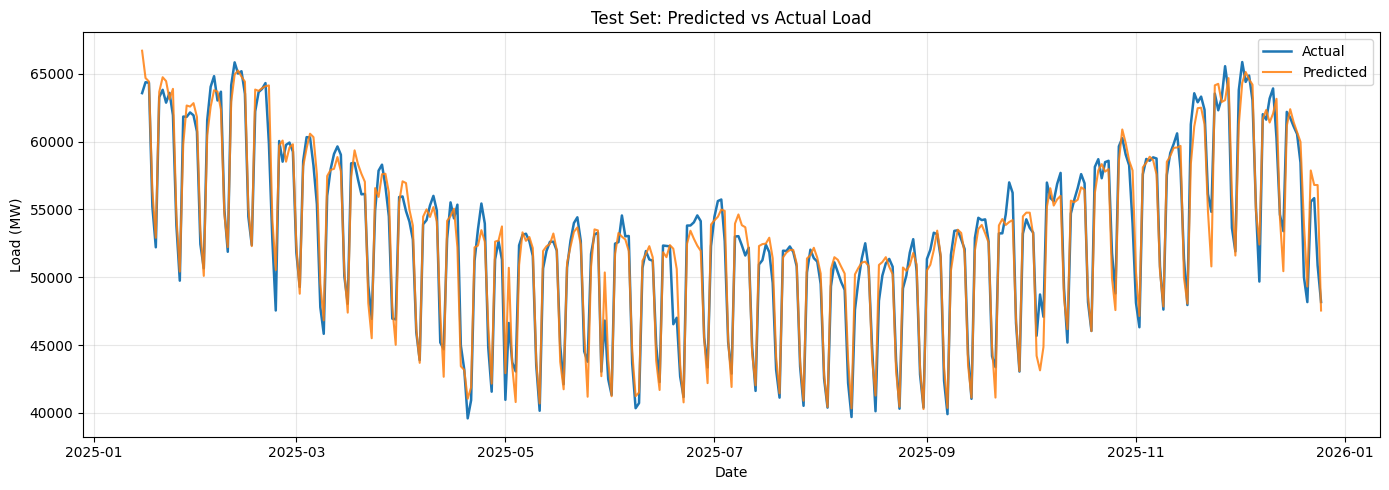

In [5]:
if not os.path.exists("models/rf_load_forecaster.joblib") or RETRAIN:
    from sklearn.ensemble import RandomForestRegressor

    rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
    rf_regressor.fit(X_train_scaled_df, y_train)

    # evaluate_and_plot_model(rf_regressor, X_val_scaled_df, y_val, val_df)
    evaluate_and_plot_model_sklearn(rf_regressor, X_test_scaled_df, y_test, test_df)

    joblib.dump(rf_regressor, "models/rf_load_forecaster.joblib")

### 2.) XGBoost Regressor


[0]	validation_0-rmse:6368.64253
[1]	validation_0-rmse:6205.74161
[2]	validation_0-rmse:6045.13247
[3]	validation_0-rmse:5896.70836
[4]	validation_0-rmse:5744.56846
[5]	validation_0-rmse:5597.69056
[6]	validation_0-rmse:5460.66432
[7]	validation_0-rmse:5340.39546
[8]	validation_0-rmse:5199.93913
[9]	validation_0-rmse:5069.17314
[10]	validation_0-rmse:4939.18294
[11]	validation_0-rmse:4817.28001
[12]	validation_0-rmse:4706.21817
[13]	validation_0-rmse:4589.39912
[14]	validation_0-rmse:4478.95762
[15]	validation_0-rmse:4367.14500
[16]	validation_0-rmse:4274.79203
[17]	validation_0-rmse:4174.61241
[18]	validation_0-rmse:4073.05947
[19]	validation_0-rmse:3980.58225
[20]	validation_0-rmse:3883.63552
[21]	validation_0-rmse:3791.45271
[22]	validation_0-rmse:3706.34616
[23]	validation_0-rmse:3628.41412
[24]	validation_0-rmse:3547.45178
[25]	validation_0-rmse:3466.70713
[26]	validation_0-rmse:3391.16420
[27]	validation_0-rmse:3315.89444
[28]	validation_0-rmse:3246.00030
[29]	validation_0-rmse:3

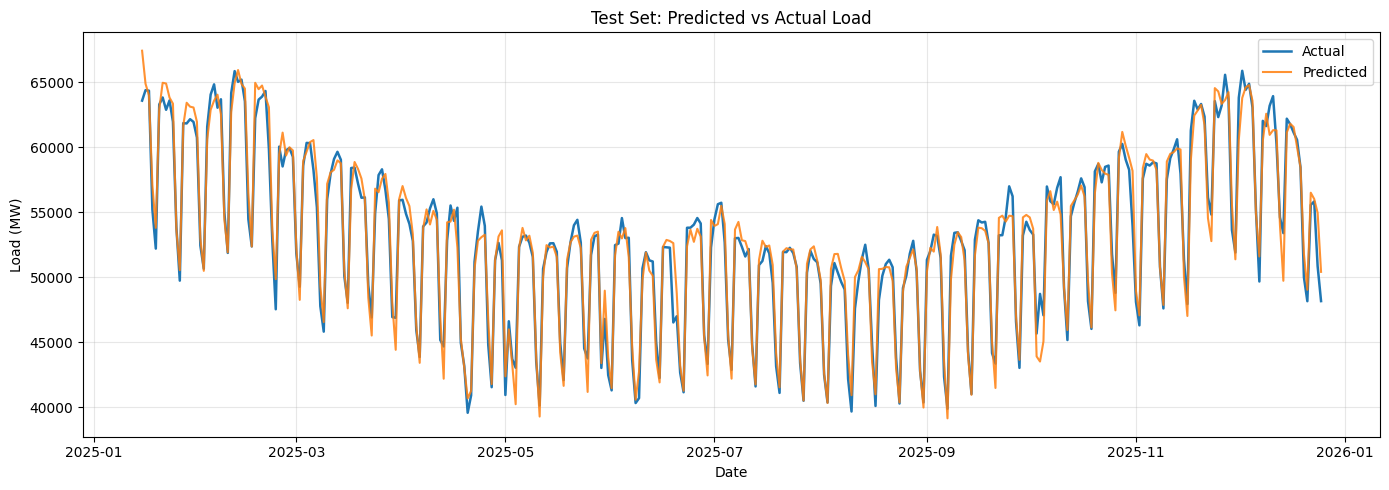

In [6]:
if not os.path.exists("models/xgb_load_forecaster.joblib") or RETRAIN:
    from xgboost import XGBRegressor

    xgb_regressor = XGBRegressor(
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        early_stopping_rounds=100
    )
    xgb_regressor.fit(X_train_scaled_df, y_train, eval_set=[(X_val_scaled_df, y_val)])

    # evaluate_and_plot_model(xgb_regressor, X_val_scaled_df, y_val, val_df)
    evaluate_and_plot_model_sklearn(xgb_regressor, X_test_scaled_df, y_test, test_df)

    joblib.dump(xgb_regressor, "models/xgb_load_forecaster.joblib")

## Feature Importance

### Permutation Invariance

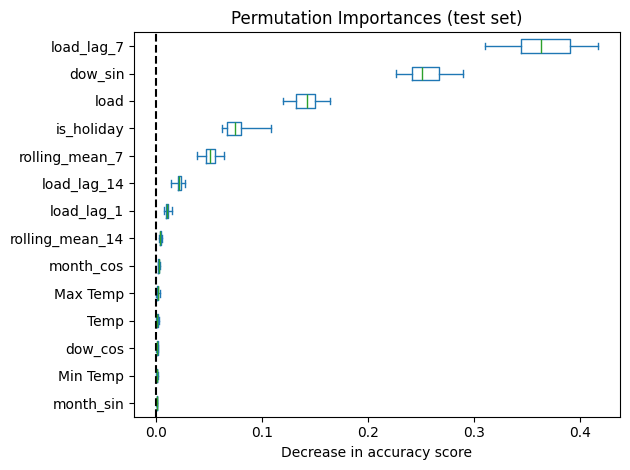

In [7]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    rf_regressor,
    X_test_scaled_df,
    y_test,
    n_repeats=30,
    random_state=42,
    n_jobs=2,
)

sorted_importances_idx = result.importances_mean.argsort()
importances = pd.DataFrame(
    result.importances[sorted_importances_idx].T,
    columns=X_test_scaled_df.columns[sorted_importances_idx],
)

ax = importances.plot.box(vert=False, whis=10)
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
ax.figure.tight_layout()

### Feature Importance XGBoost

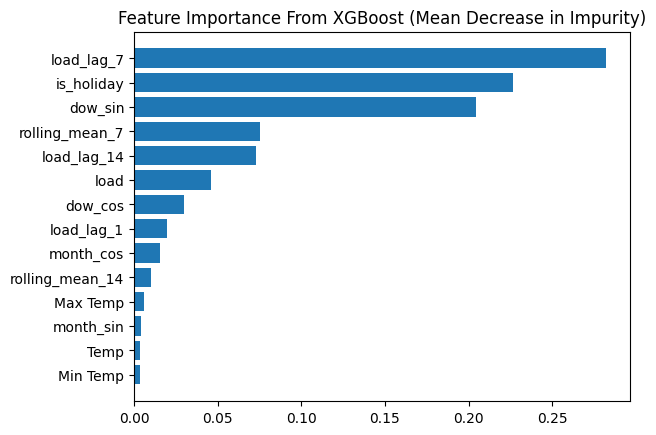

In [8]:
import matplotlib.pyplot as plt

importances = xgb_regressor.feature_importances_

plt.barh(X_train.columns[np.argsort(importances)], importances[np.argsort(importances)])
plt.title("Feature Importance From XGBoost (Mean Decrease in Impurity)")
plt.show()

### SHAP

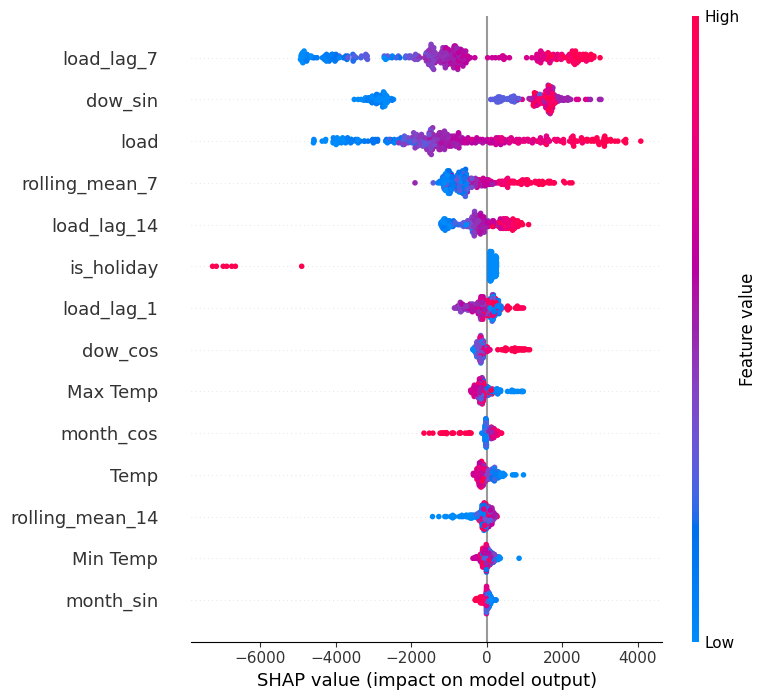

In [9]:
import shap
explainer = shap.Explainer(xgb_regressor)
shap_values = explainer(X_test_scaled_df)
shap.summary_plot(shap_values, X_test_scaled_df)

In [10]:
# As a result of the feature importance analysis, it is evident that the following features do not contribute significantly to the model's predictive performance 
# and can be removed without negatively impacting the model's accuracy:
# - Cooling Degrees 
# - Sunshine Duration
# - Cloud Cover
# - Heating Degrees 
# - Wind Speed
# - Standard deviation features of the load (std_7, std_14) 